In [1]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

In [2]:
df_train = pd.read_csv(f"data-00-raw/bike_train.csv", index_col=[0], parse_dates=["date"])

df_train

,date,wcond,temp,atemp,hum,wind,count
1,2022-01-01,2,9.1,13.2,79.78,10.43,982
2,2022-01-02,2,9.9,12.7,68.91,16.16,797
3,2022-01-03,1,3.1,4.5,43.29,16.14,1351
4,2022-01-04,1,3.2,5.6,58.45,10.42,1559
5,2022-01-05,1,4.3,6.5,43.26,12.15,1597
...,...,...,...,...,...,...,...
361,2022-12-27,2,8.3,11.4,75.49,12.25,1161
362,2022-12-28,1,7.3,9.0,49.89,19.11,2301
363,2022-12-29,1,5.2,8.2,56.84,7.76,2421
364,2022-12-30,1,7.8,10.9,63.03,8.73,2995


In [3]:
df_test = pd.read_csv(f"data-00-raw/bike_test.csv", index_col=[0], parse_dates=["date"])

df_test

,date,wcond,temp,atemp,hum,wind
1,2023-01-01,1,10.2,13.8,68.56,12.49
2,2023-01-02,1,6.2,7.6,37.75,21.43
3,2023-01-03,1,1.1,1.3,43.68,23.77
4,2023-01-04,2,-0.6,1.0,41.04,12.01
5,2023-01-05,1,5.9,8.9,51.89,8.45
...,...,...,...,...,...,...
361,2023-12-27,3,5.0,6.0,81.51,20.58
362,2023-12-28,2,5.4,6.3,64.64,22.76
363,2023-12-29,2,5.4,7.8,58.41,10.11
364,2023-12-30,2,5.4,7.1,74.54,8.08


# Features Engineering

In [4]:
import holidays

In [5]:
def add_fourier_features(df: pd.DataFrame, n_harmonics: int = 3) -> pd.DataFrame:
    """Add Fourier seasonality terms for annual cycle.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with ``dayofyear`` column.
    n_harmonics : int
        Number of harmonics to generate.

    Returns
    -------
    pd.DataFrame
        DataFrame with added sin/cos Fourier columns.
    """
    for k in range(1, n_harmonics + 1):
        df[f"sin_doy_{k}"] = np.sin(2 * np.pi * k * df["dayofyear"] / 365)
        df[f"cos_doy_{k}"] = np.cos(2 * np.pi * k * df["dayofyear"] / 365)
    return df

def build_features(
        df: pd.DataFrame,
        to_drop_at_end: list[str]|None = None
    ) -> pd.DataFrame:
    """Build full feature matrix from raw bike sharing data.

    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame with columns: date, temp, atemp, hum, wind, wcond.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered features, without target column.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    df["month"] = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek
    df["dayofyear"] = df["date"].dt.dayofyear
    df["quarter"] = df["date"].dt.quarter
    df["weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["doy_normalized"] = df["dayofyear"] / 365

    df["t"] = (df["date"] - pd.Timestamp("2022-01-01")).dt.days

    df["temp_sq"] = df["temp"] ** 2
    df["temp_cube"] = df["temp"] ** 3
    df["hum_sq"] = df["hum"] ** 2
    df["wind_sq"] = df["wind"] ** 2
    df["temp_atemp_diff"] = df["temp"] - df["atemp"]

    df["temp_x_hum"] = df["temp"] * df["hum"]
    df["temp_x_wind"] = df["temp"] * df["wind"]
    df["atemp_x_hum"] = df["atemp"] * df["hum"]
    df["hum_x_wind"] = df["hum"] * df["wind"]
    df["wcond_x_temp"] = df["wcond"] * df["temp"]

    df["is_summer"] = df["month"].isin([6, 7, 8]).astype(int)
    df["is_winter"] = df["month"].isin([12, 1, 2]).astype(int)

    wcond_dummies = pd.get_dummies(df["wcond"], prefix="wcond", drop_first=True)
    df = pd.concat([df, wcond_dummies], axis=1)

    df = add_fourier_features(df)

    drop_cols = ["date", "wcond", "dayofyear"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    if to_drop_at_end is not None:
        df = df.drop(columns=to_drop_at_end, errors='ignore')
    return df

In [6]:
pl_holidays_2022 = holidays.Poland(years=2022)

df_train_featured = df_train.copy()

df_train_featured["is_holiday"] = df_train_featured["date"].isin(pl_holidays_2022).astype(int)

df_train_featured = build_features(
    df_train_featured,
    # to_drop_at_end=["temp_cube", "wcond_x_temp", "hum_x_wind", "is_summer", "is_winter", "is_holiday", "is_free_day"]
)

df_train_featured

,temp,atemp,hum,wind,count,is_holiday,month,dayofweek,quarter,weekend,...,is_summer,is_winter,wcond_2,wcond_3,sin_doy_1,cos_doy_1,sin_doy_2,cos_doy_2,sin_doy_3,cos_doy_3
1,9.1,13.2,79.78,10.43,982,0,1,5,1,1,...,0,1,True,False,1.721336e-02,0.999852,3.442161e-02,0.999407,5.161967e-02,0.998667
2,9.9,12.7,68.91,16.16,797,0,1,6,1,1,...,0,1,True,False,3.442161e-02,0.999407,6.880243e-02,0.997630,1.031017e-01,0.994671
3,3.1,4.5,43.29,16.14,1351,0,1,0,1,0,...,0,1,False,False,5.161967e-02,0.998667,1.031017e-01,0.994671,1.543088e-01,0.988023
4,3.2,5.6,58.45,10.42,1559,0,1,1,1,0,...,0,1,False,False,6.880243e-02,0.997630,1.372788e-01,0.990532,2.051045e-01,0.978740
5,4.3,6.5,43.26,12.15,1597,0,1,2,1,0,...,0,1,False,False,8.596480e-02,0.996298,1.712931e-01,0.985220,2.553533e-01,0.966848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,8.3,11.4,75.49,12.25,1161,0,12,1,4,0,...,0,1,True,False,-6.880243e-02,0.997630,-1.372788e-01,0.990532,-2.051045e-01,0.978740
362,7.3,9.0,49.89,19.11,2301,0,12,2,4,0,...,0,1,False,False,-5.161967e-02,0.998667,-1.031017e-01,0.994671,-1.543088e-01,0.988023
363,5.2,8.2,56.84,7.76,2421,0,12,3,4,0,...,0,1,False,False,-3.442161e-02,0.999407,-6.880243e-02,0.997630,-1.031017e-01,0.994671
364,7.8,10.9,63.03,8.73,2995,0,12,4,4,0,...,0,1,False,False,-1.721336e-02,0.999852,-3.442161e-02,0.999407,-5.161967e-02,0.998667


In [7]:
pl_holidays_2023 = holidays.Poland(years=2023)

df_test_featured = df_test.copy()

df_test_featured["is_holiday"] = df_test_featured["date"].isin(pl_holidays_2023).astype(int)

df_test_featured = build_features(
    df_test_featured, 
    # to_drop_at_end=["temp_cube", "wcond_x_temp", "hum_x_wind", "is_summer", "is_winter", "is_holiday", "is_free_day"]
)

df_test_featured

,temp,atemp,hum,wind,is_holiday,month,dayofweek,quarter,weekend,doy_normalized,...,is_summer,is_winter,wcond_2,wcond_3,sin_doy_1,cos_doy_1,sin_doy_2,cos_doy_2,sin_doy_3,cos_doy_3
1,10.2,13.8,68.56,12.49,0,1,6,1,1,0.002740,...,0,1,False,False,1.721336e-02,0.999852,3.442161e-02,0.999407,5.161967e-02,0.998667
2,6.2,7.6,37.75,21.43,0,1,0,1,0,0.005479,...,0,1,False,False,3.442161e-02,0.999407,6.880243e-02,0.997630,1.031017e-01,0.994671
3,1.1,1.3,43.68,23.77,0,1,1,1,0,0.008219,...,0,1,False,False,5.161967e-02,0.998667,1.031017e-01,0.994671,1.543088e-01,0.988023
4,-0.6,1.0,41.04,12.01,0,1,2,1,0,0.010959,...,0,1,True,False,6.880243e-02,0.997630,1.372788e-01,0.990532,2.051045e-01,0.978740
5,5.9,8.9,51.89,8.45,0,1,3,1,0,0.013699,...,0,1,False,False,8.596480e-02,0.996298,1.712931e-01,0.985220,2.553533e-01,0.966848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,5.0,6.0,81.51,20.58,0,12,2,4,0,0.989041,...,0,1,False,True,-6.880243e-02,0.997630,-1.372788e-01,0.990532,-2.051045e-01,0.978740
362,5.4,6.3,64.64,22.76,0,12,3,4,0,0.991781,...,0,1,True,False,-5.161967e-02,0.998667,-1.031017e-01,0.994671,-1.543088e-01,0.988023
363,5.4,7.8,58.41,10.11,0,12,4,4,0,0.994521,...,0,1,True,False,-3.442161e-02,0.999407,-6.880243e-02,0.997630,-1.031017e-01,0.994671
364,5.4,7.1,74.54,8.08,0,12,5,4,1,0.997260,...,0,1,True,False,-1.721336e-02,0.999852,-3.442161e-02,0.999407,-5.161967e-02,0.998667


### X_[train|test] + y_[train] 

In [8]:
X = df_train_featured.drop(columns=["count"]).to_numpy()

y_log = np.log1p(df_train_featured["count"].to_numpy())

In [9]:
X_test = df_test_featured.to_numpy()

# Grid making

In [10]:
param_grid = {
    "n_estimators": [300, 500, 1000],
    "max_depth": [5, 7, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 5],  
    "max_features": ["sqrt", "log2", 0.5],
    "min_samples_split": [2, 4, 8]
}

# Training

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, ParameterGrid, cross_validate
from sklearn.metrics import root_mean_squared_error as rmse

from tqdm import tqdm

In [12]:
kf = GroupKFold(n_splits=6)

groups: np.ndarray = df_train["date"].dt.isocalendar().week.astype(int).to_numpy()

### Training itself

In [ ]:
results = []
for params in tqdm(ParameterGrid(param_grid)):
    rf = RandomForestRegressor(**params, random_state=RANDOM_STATE)
    train_rmses, val_rmses = [], []
    for train_idx, val_idx in kf.split(X, y_log, groups=groups):
        rf.fit(X[train_idx], y_log[train_idx])
        train_pred = np.expm1(rf.predict(X[train_idx]))
        val_pred   = np.expm1(rf.predict(X[val_idx]))
        y_train_orig = np.expm1(y_log[train_idx])
        y_val_orig   = np.expm1(y_log[val_idx])
        train_rmses.append(rmse(y_train_orig, train_pred))
        val_rmses.append(rmse(y_val_orig, val_pred))

    results.append(
        {
            **params,
            "train_rmse_mean": np.mean(train_rmses),
            "train_rmse_std": np.std(train_rmses),
            "val_rmse_mean": np.mean(val_rmses),
            "val_rmse_std": np.std(val_rmses),
        }
    )

100%|██████████| 486/486 [16:44<00:00,  2.07s/it]


### Results Plot

# Results

In [14]:
best_idx = np.argmin([r["val_rmse"][0] for r in results])
best = results[best_idx]
best_rmse = best["val_rmse"][0]

In [23]:
print(f"[RandomForest]\nParams: {best}\nused_df: {"Features Engineering"}")
print(f"CV-RMSE: {best_rmse:.2f}")

[RandomForest]
Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 300, 'train_rmse': (np.float64(203.3575557008428), np.float64(5.205721663299689)), 'val_rmse': (np.float64(532.4171946773116), np.float64(58.32532455338697))}
used_df: Features Engineering
CV-RMSE: 532.42


### Results Plot

In [24]:
import matplotlib.pyplot as plt

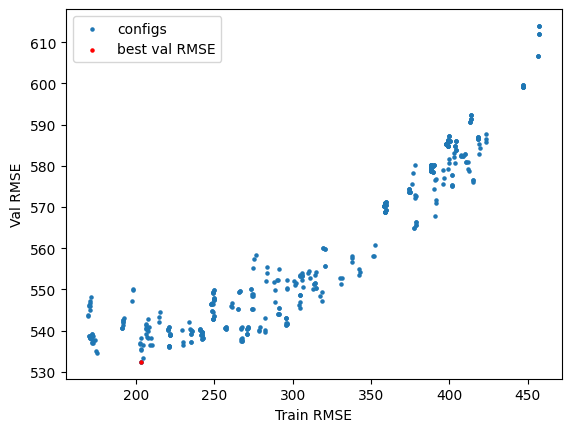

In [35]:

train_rmse = [r["train_rmse"][0] for r in results]
val_rmse   = [r["val_rmse"][0]   for r in results]

fig, ax = plt.subplots()
ax.scatter(train_rmse, val_rmse, alpha=1, s=5, label="configs")
ax.scatter(train_rmse[best_idx], val_rmse[best_idx], s=5, color="red", label="best val RMSE")
ax.set_xlabel("Train RMSE")
ax.set_ylabel("Val RMSE")
ax.legend()
plt.show()

# Running best model

In [26]:
best_params = {k: best[k] for k in param_grid.keys()}
rf_best = RandomForestRegressor(**best_params, random_state=RANDOM_STATE)
rf_best.fit(X, y_log)
preds = np.expm1(rf_best.predict(X_test).clip(0))

# Submission Generator

In [27]:
from scripts.save_submission import save_submission_csv

In [28]:
df_date = pd.read_csv(f"data-00-raw/bike_test.csv", parse_dates=["date"])

df_date["date"]

0     2023-01-01
1     2023-01-02
2     2023-01-03
3     2023-01-04
4     2023-01-05
         ...    
360   2023-12-27
361   2023-12-28
362   2023-12-29
363   2023-12-30
364   2023-12-31
Name: date, Length: 365, dtype: datetime64[us]

In [29]:
df_submission = pd.DataFrame({"date": df_date["date"], "pred": preds})

df_submission

,date,pred
0,2023-01-01,1460.677698
1,2023-01-02,1583.023610
2,2023-01-03,1366.542052
3,2023-01-04,1421.461008
4,2023-01-05,1657.446678
...,...,...
360,2023-12-27,1175.487162
361,2023-12-28,1633.557975
362,2023-12-29,2039.987423
363,2023-12-30,1905.846285


In [30]:
save_submission_csv(df_submission)

# Results Exploration

In [39]:
import pickle

In [45]:
for result in results:
    print(result["val_rmse"])

(np.float64(576.9718072447973), np.float64(75.3540944472897))
(np.float64(575.5514174700442), np.float64(75.41169140689023))
(np.float64(578.9742379716398), np.float64(73.50557660476319))
(np.float64(581.7132891939891), np.float64(72.98077229638004))
(np.float64(579.1331637543111), np.float64(72.72027648888763))
(np.float64(580.7390079088783), np.float64(72.04360744415668))
(np.float64(581.015631026681), np.float64(73.04885851093272))
(np.float64(579.261471747889), np.float64(72.01433252329308))
(np.float64(578.8293975238976), np.float64(70.6920368796314))
(np.float64(577.8390484932368), np.float64(76.89790186411602))
(np.float64(575.1569981879649), np.float64(76.04658027276332))
(np.float64(575.4001744420721), np.float64(73.37484962120587))
(np.float64(577.8390484932368), np.float64(76.89790186411602))
(np.float64(575.1569981879649), np.float64(76.04658027276332))
(np.float64(575.4001744420721), np.float64(73.37484962120587))
(np.float64(576.1368661046064), np.float64(73.3683826213355

In [46]:
with open(f"params-random-forest/random_forest_0.pkl", "wb") as f:
    pickle.dump(results, f)